# AI Business Sector Classification

**Purpose:** Standardize ~3000 unique business categories into canonical NAICS-like taxonomy

This notebook uses a two-phase approach to standardize business categories:
- **Rule-based mapping** for common/clear categories
- **AI classification** using OpenAI for ambiguous cases

**Features:**
- **Dual data sources** - Load from local JSON files or remote PostgreSQL database
    - **VPN REQUIRED** for Remote
- **Parallel processing** - Process multiple categories concurrently for speed
- **Data quality validation** - Ensure Neo4j graph database compatibility
- **LLM on/off control** - Enable LLM by providing API key in .env, disable by removing it
- **Comprehensive outputs** - Standardized JSON with detailed mapping reports

**Classification Strategy:**
- Primary: Rule-based keyword matching (fast, free)
- Secondary: Fast LLM (gpt-4o-mini) for partial matches and ambiguous cases
- Third: Advanced LLM (gpt-4o) for low-confidence classifications

## Configuration

Set up data sources, API credentials, and processing parameters.

**Mode Selection:**
- `test` - Process only limited businesses to verify setup
- `live` - Process entire dataset

**Data Source Options:**
- `local` - Read from JSON file on disk
- `database` - Query PostgreSQL database directly (with automatic fallback to local)

**LLM Control:**
- LLM is enabled if OPENAI_API_KEY is found in .env file
- If LLM disabled: Only rule-based classification (partial matches marked unverified)
- If LLM enabled: Full three-tier system (rule-based -> fast LLM -> advanced LLM)

**Recommended workflow:**
1. Run in `test` mode first to verify everything works
2. Review test results and adjust parameters if needed
3. Switch to `live` mode for full dataset processing

In [3]:
import json
import os
import re
import asyncio
from pathlib import Path
from collections import defaultdict, Counter
from typing import Any, Dict, List, Set, Tuple, Optional
from openai import AsyncOpenAI
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv('.env')

# ==================== MODE SELECTION ====================
# Choose: 'test' or 'live'
MODE = 'live'  # 'test' processes only TEST_LIMIT businesses, 'live' processes all
TEST_LIMIT = 1000  # Number of businesses to process in test mode
# ==================== DATA SOURCE SELECTION ====================
# Choose: 'local' or 'database'
DATA_SOURCE = 'local'  # Change to 'database' to use PostgreSQL

# ==================== OUTPUT MODE ====================
# Choose: 'single' or 'full'
# 'single' - Only creates enriched JSON file
# 'full' - Creates enriched JSON + analysis JSON + summary JSON + mapping report
OUTPUT_MODE = 'single'

# ==================== LOCAL FILE CONFIGURATION ====================
LOCAL_FILE_PATH = '../data/llm/local_data/sd_businesses_franchise_classification.json'

# ==================== DATABASE CONFIGURATION ====================
# PostgreSQL connection (for DATA_SOURCE='database')
DB_HOST = 'awesome-hw.sdsc.edu'
DB_PORT = '5432'
DB_NAME = 'nourish'
DB_USER = ''
DB_PASSWORD = ''
DB_TABLE = 'ca_businesses_with_ai_franchise'

# ==================== OPENAI CONFIGURATION ====================
# Load API key from .env file
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
if not OPENAI_API_KEY:
    print("WARNING: OPENAI_API_KEY not found - LLM disabled")

# ==================== AI MODEL CONFIGURATION ====================
PRIMARY_MODEL = 'gpt-4o-mini'  # Fast, cost-effective initial classification
ADVANCED_MODEL = 'gpt-4o'  # More thorough model for low-confidence cases
CONFIDENCE_THRESHOLD = 0.7  # Re-analyze if confidence below this

# ==================== PARALLEL PROCESSING ====================
MAX_CONCURRENT_REQUESTS = 5  # Process this many categories simultaneously

# ==================== OUTPUT CONFIGURATION ====================
OUTPUT_DIR = '../data/llm'
OUTPUT_FILENAME = 'sd_businesses.json'
DELETE_INPUT_AFTER = False  # Set to True to delete input file after processing
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Config loaded: {MODE} mode, {DATA_SOURCE} source, LLM {'ON' if OPENAI_API_KEY else 'OFF'}")

Config loaded: live mode, local source, LLM ON


## Canonical Taxonomy

NAICS-inspired taxonomy structure for business classification. This hierarchical taxonomy is used for both rule-based and LLM classification.

In [4]:
CANONICAL_TAXONOMY = {
    "Food & Beverage": {
        "Restaurants": ["restaurant", "cafe", "diner", "eatery", "bistro", "grill"],
        "Fast Food": ["fast food", "quick service", "burger", "pizza", "sandwich", "taco"],
        "Coffee & Tea": ["coffee", "tea", "espresso", "cafe", "coffeehouse"],
        "Bars & Nightlife": ["bar", "pub", "lounge", "nightclub", "brewery", "tavern"],
        "Bakery & Desserts": ["bakery", "pastry", "dessert", "ice cream", "donut", "cake"],
        "Specialty Food": ["deli", "grocery", "market", "butcher", "seafood", "organic"]
    },

    "Retail": {
        "Clothing & Apparel": ["clothing", "apparel", "fashion", "boutique", "shoes", "accessories"],
        "General Merchandise": ["department store", "variety store", "discount", "warehouse", "convenience", "outlet"],
        "Specialty Retail": ["gift", "toys", "books", "music", "electronics", "hobby"],
        "Home & Garden": ["furniture", "home decor", "garden", "hardware", "appliances"],
        "Automotive Retail": ["auto parts", "tire", "accessories", "motorcycle"]
    },

    "Personal Services": {
        "Health & Beauty": ["salon", "spa", "barber", "nail", "beauty", "massage", "cosmetic"],
        "Fitness & Recreation": ["gym", "fitness", "yoga", "pilates", "martial arts", "dance", "trainer"],
        "Dry Cleaning & Laundry": ["dry clean", "laundry", "alterations"],
        "Pet Services": ["pet grooming", "veterinary", "pet store", "animal"]
    },

    "Professional Services": {
        "Financial Services": ["bank", "credit union", "insurance", "financial", "investment", "tax"],
        "Real Estate": ["real estate", "property management", "realty"],
        "Legal Services": ["attorney", "lawyer", "legal", "law office"],
        "Accounting": ["accounting", "cpa", "bookkeeping"],
        "Business Services": ["printing", "shipping", "mailing", "packaging", "copy"]
    },

    "Healthcare": {
        "Medical Offices": ["doctor", "physician", "clinic", "medical"],
        "Dental": ["dentist", "dental", "orthodont"],
        "Pharmacy": ["pharmacy", "drugstore", "prescription"],
        "Specialized Healthcare": ["chiropractor", "optometry", "physical therapy", "acupuncture"],
        "Mental Health": ["counseling", "therapy", "psychologist", "psychiatrist"]
    },

    "Automotive Services": {
        "Repair & Maintenance": ["auto repair", "mechanic", "oil change", "brake", "muffler", "smog"],
        "Car Wash & Detailing": ["car wash", "detailing", "auto spa"],
        "Towing & Roadside": ["towing", "roadside", "wrecker"],
        "Gas Stations": ["gas station", "fuel", "petrol"]
    },

    "Home Services": {
        "Construction & Contractors": ["construction", "contractor", "builder", "remodeling"],
        "Plumbing & HVAC": ["plumbing", "plumber", "hvac", "heating", "cooling", "air conditioning"],
        "Electrical": ["electrical", "electrician"],
        "Cleaning Services": ["cleaning", "janitorial", "maid", "housekeeping"],
        "Landscaping": ["landscaping", "lawn care", "tree service", "gardening"]
    },

    "Education & Childcare": {
        "Schools": ["school", "academy", "learning center", "education"],
        "Tutoring": ["tutoring", "tutor", "test prep"],
        "Childcare": ["daycare", "preschool", "child care", "nursery"]
    },

    "Entertainment & Recreation": {
        "Arts & Entertainment": ["theater", "cinema", "movie", "entertainment", "museum"],
        "Sports & Recreation": ["sports", "recreation", "bowling", "golf", "skating"],
        "Events & Venues": ["event", "venue", "banquet", "catering"]
    },

    "Lodging": {
        "Hotels & Motels": ["hotel", "motel", "inn", "lodge"],
        "Alternative Lodging": ["bed and breakfast", "hostel", "vacation rental"]
    },

    "Technology": {
        "IT Services": ["computer repair", "it services", "tech support", "software"],
        "Telecommunications": ["wireless", "phone", "mobile", "telecom"]
    },

    "Other Services": {
        "Business Services": ["printing", "shipping", "mailing", "packaging", "copy"],
        "Travel Services": ["travel agency", "travel", "tour"],
        "Miscellaneous": []
    }
}

print(f"Loaded canonical taxonomy with {len(CANONICAL_TAXONOMY)} sectors")

Loaded canonical taxonomy with 12 sectors


## Initialize OpenAI Client

Initialize async OpenAI client for parallel API requests (if LLM enabled).

In [5]:
# Initialize OpenAI client if API key is available
client = None
if OPENAI_API_KEY:
    try:
        client = AsyncOpenAI(api_key=OPENAI_API_KEY)
        print(f"OpenAI client initialized successfully")
        print(f"  Primary model: {PRIMARY_MODEL}")
        print(f"  Advanced model: {ADVANCED_MODEL}")
    except Exception as e:
        print(f"Failed to initialize OpenAI client: {e}")
        print("LLM classification will be disabled")
        client = None
else:
    print("LLM classification disabled - no API key provided")

OpenAI client initialized successfully
  Primary model: gpt-4o-mini
  Advanced model: gpt-4o


## Load Business Data

Load business records from selected data source. Database mode queries PostgreSQL with automatic fallback to local file.

In [6]:
# Load business data from selected source
businesses = []

if DATA_SOURCE.lower() == 'database':
    print(f"Attempting to load data from PostgreSQL database...")
    print(f"  Host: {DB_HOST}")
    print(f"  Database: {DB_NAME}")
    print(f"  Table: {DB_TABLE}")
    
    try:
        import subprocess
        import sys
        
        # Build psql command
        psql_cmd = f'psql -h {DB_HOST} -p {DB_PORT} -U {DB_USER} -d {DB_NAME} -t -A -F"," -c "SELECT row_to_json(t) FROM (SELECT * FROM {DB_TABLE}) t"'
        
        print("Executing database query...")
        result = subprocess.run(
            psql_cmd,
            shell=True,
            capture_output=True,
            text=True,
            timeout=300
        )
        
        if result.returncode == 0:
            lines = result.stdout.strip().split('\n')
            for line in lines:
                if line.strip():
                    try:
                        businesses.append(json.loads(line))
                    except json.JSONDecodeError:
                        continue
            
            print(f"[OK] Loaded {len(businesses):,} businesses from database")
        else:
            print(f"[ERROR] Database query failed: {result.stderr}")
            print(f"Falling back to local file: {LOCAL_FILE_PATH}")
            DATA_SOURCE = 'local'
    
    except Exception as e:
        print(f"[ERROR] Database connection failed: {e}")
        print(f"Falling back to local file: {LOCAL_FILE_PATH}")
        DATA_SOURCE = 'local'

if DATA_SOURCE.lower() == 'local':
    print(f"Loading data from local file: {LOCAL_FILE_PATH}")
    
    if not os.path.exists(LOCAL_FILE_PATH):
        raise FileNotFoundError(f"Local file not found: {LOCAL_FILE_PATH}")
    
    with open(LOCAL_FILE_PATH, 'r', encoding='utf-8') as f:
        businesses = json.load(f)
    
    print(f"[OK] Loaded {len(businesses):,} businesses from local file")

# Apply test mode limit if enabled
if MODE.lower() == 'test' and len(businesses) > TEST_LIMIT:
    print(f"\nTest mode enabled - limiting to {TEST_LIMIT:,} businesses (out of {len(businesses):,})")
    businesses = businesses[:TEST_LIMIT]

print(f"\nFinal dataset: {len(businesses):,} businesses")

Loading data from local file: ../data/llm/local_data/sd_businesses_franchise_classification.json
[OK] Loaded 39,593 businesses from local file

Final dataset: 39,593 businesses


## Category Analysis

Analyze category distribution to understand standardization scope.

In [7]:
all_categories = []
for business in businesses:
    categories = business.get('categories', [])
    if isinstance(categories, list):
        all_categories.extend([cat for cat in categories if cat])
    elif isinstance(categories, str) and categories.strip():
        all_categories.append(categories.strip())

unique_categories = sorted(set(all_categories))
category_counts = Counter(all_categories)

print(f"Total category instances: {len(all_categories):,}")
print(f"Unique categories: {len(unique_categories):,}")
print(f"\nTop 15 categories:")
for i, (cat, count) in enumerate(category_counts.most_common(15), 1):
    print(f"  {i:2}. {cat:40} {count:5}")

Total category instances: 96,262
Unique categories: 2,934

Top 15 categories:
   1. Restaurant                                3124
   2. Mexican restaurant                        1121
   3. Fast food restaurant                      1057
   4. Auto repair shop                          1019
   5. Coffee shop                                980
   6. Bar                                        876
   7. Breakfast restaurant                       835
   8. Cafe                                       805
   9. Beauty salon                               786
  10. American restaurant                        765
  11. Clothing store                             749
  12. Sandwich shop                              711
  13. Tourist attraction                         697
  14. Caterer                                    672
  15. Hair salon                                 664


## Classification Functions

Three-tier classification: Rule-based -> Fast LLM (gpt-4o-mini) -> Advanced LLM (gpt-4o).

Parallel processing with smart escalation for low-confidence results.

In [8]:
# Build keyword lookup map from taxonomy for fast rule-based matching
category_map = {}
for sector, subsectors in CANONICAL_TAXONOMY.items():
    for subsector, keywords in subsectors.items():
        for keyword in keywords:
            category_map[keyword.lower()] = (sector, subsector)

# Semaphore for limiting concurrent API requests
semaphore = asyncio.Semaphore(MAX_CONCURRENT_REQUESTS)

def normalize_category(category: str) -> str:
    """Normalize category name by removing common suffixes and extra whitespace."""
    if not category:
        return ""
    normalized = category.lower().strip()
    # Remove common business suffixes
    normalized = re.sub(r'\s*(services?|store|shop|center|company|inc\.?|llc|corp\.?)\s*$', '', normalized)
    # Collapse multiple spaces
    normalized = re.sub(r'\s+', ' ', normalized)
    return normalized

def rule_based_classification(category: str) -> Optional[Tuple[str, str, float, bool]]:
    """
    Classify category using keyword matching against taxonomy.
    
    Returns:
        Tuple of (sector, subsector, confidence, needs_verification) or None if no match
    """
    normalized = normalize_category(category)
    if not normalized:
        return None

    # Find all keyword matches and score them
    matches = []
    for keyword, (sector, subsector) in category_map.items():
        if keyword in normalized:
            # Exact match - highest confidence, no verification needed
            if normalized == keyword:
                confidence = 1.0
                match_quality = len(keyword)
                needs_verification = False
            # Prefix/suffix match - high confidence, no verification needed
            elif normalized.startswith(keyword) or normalized.endswith(keyword):
                confidence = 0.9
                match_quality = len(keyword) * 0.9
                needs_verification = False
            # Partial match - good confidence, but verify with LLM if available
            else:
                confidence = 0.8
                match_quality = len(keyword) * 0.8
                needs_verification = True
            matches.append((sector, subsector, confidence, match_quality, needs_verification, keyword))

    if not matches:
        return None

    # Return best match based on confidence and match quality
    best_match = max(matches, key=lambda x: (x[2], x[3]))
    return (best_match[0], best_match[1], best_match[2], best_match[4])

async def llm_classification_single(category: str, model: str, is_reanalysis: bool = False, 
                                     initial_result: Optional[Dict] = None) -> Optional[Dict]:
    """
    Classify a single category using LLM.
    
    Args:
        category: Business category to classify
        model: Model name to use (PRIMARY_MODEL or ADVANCED_MODEL)
        is_reanalysis: If True, this is reanalysis after low confidence
        initial_result: Previous classification result (if reanalysis)
    
    Returns:
        Dict with sector, subsector, confidence or None on error
    """
    if not client:
        return None
    
    # Build taxonomy description for LLM prompt
    taxonomy_desc = []
    for sector, subsectors in CANONICAL_TAXONOMY.items():
        subsector_names = ", ".join(subsectors.keys())
        taxonomy_desc.append(f"{sector}: {subsector_names}")
    taxonomy_str = "\n".join(taxonomy_desc)
    
    # Build system message based on analysis type
    if is_reanalysis and initial_result:
        system_msg = f"This business category requires more thorough analysis. Initial classification returned low confidence ({initial_result.get('confidence', 0.0):.2f}). Previous: {initial_result.get('standardized_sector')} - {initial_result.get('standardized_subsector')}. Perform detailed analysis to classify into the taxonomy. Return ONLY a JSON object: {{\"sector\": \"...\", \"subsector\": \"...\", \"confidence\": 0.0-1.0}}"
    else:
        system_msg = "You are a business classification expert. Classify this category into the provided taxonomy. Return ONLY a JSON object: {\"sector\": \"...\", \"subsector\": \"...\", \"confidence\": 0.0-1.0}"
    
    user_msg = f"Classify: {category}\n\nTaxonomy:\n{taxonomy_str}\n\nRules:\n- sector and subsector must come from the taxonomy\n- confidence must be between 0.0 and 1.0\n- If uncertain, use: sector=\"Other Services\", subsector=\"Miscellaneous\", confidence=0.5"
    
    try:
        # Call OpenAI API with semaphore for rate limiting
        async with semaphore:
            response = await client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_msg},
                    {"role": "user", "content": user_msg},
                ],
                temperature=0.3 if is_reanalysis else 0.1
            )
        
        result_text = response.choices[0].message.content.strip()
        
        # Parse JSON from response
        try:
            parsed = json.loads(result_text)
        except json.JSONDecodeError:
            # Try to extract JSON from markdown or other formatting
            json_match = re.search(r"\{.*\}", result_text, re.DOTALL)
            if not json_match:
                return None
            parsed = json.loads(json_match.group())
        
        # Validate response structure
        if not isinstance(parsed, dict):
            return None
        
        sector = parsed.get("sector")
        subsector = parsed.get("subsector")
        confidence = float(parsed.get("confidence", 0.5))
        
        # Verify sector and subsector exist in taxonomy
        if sector in CANONICAL_TAXONOMY and subsector in CANONICAL_TAXONOMY[sector]:
            return {"sector": sector, "subsector": subsector, "confidence": confidence}
        
        return None
    
    except Exception as e:
        return None

async def classify_category_full(category: str) -> Dict[str, Any]:
    """
    Full three-tier classification: Rule-based -> Fast LLM -> Advanced LLM.
    
    Process:
    1. Try rule-based classification first
    2. If rule match needs verification, use fast LLM
    3. If fast LLM has low confidence, escalate to advanced LLM
    4. If no rule match, go directly to fast LLM (with advanced escalation)
    
    Args:
        category: Business category to classify
    
    Returns:
        Dict with classification results and metadata
    """
    # Try rule-based classification first
    rule_result = rule_based_classification(category)
    
    if rule_result:
        sector, subsector, confidence, needs_verification = rule_result
        
        # High-confidence rule match - use it directly
        if not needs_verification:
            return {
                "original_category": category,
                "standardized_sector": sector,
                "standardized_subsector": subsector,
                "confidence": confidence,
                "method": "rule_based"
            }
        
        # Partial rule match - verify with LLM if available
        if client:
            llm_result = await llm_classification_single(category, PRIMARY_MODEL)
            if llm_result:
                initial_confidence = llm_result["confidence"]
                
                # Low confidence from fast LLM - escalate to advanced model
                if initial_confidence < CONFIDENCE_THRESHOLD:
                    advanced_result = await llm_classification_single(
                        category, ADVANCED_MODEL, is_reanalysis=True, 
                        initial_result={
                            "standardized_sector": llm_result["sector"],
                            "standardized_subsector": llm_result["subsector"],
                            "confidence": initial_confidence
                        }
                    )
                    
                    if advanced_result:
                        return {
                            "original_category": category,
                            "standardized_sector": advanced_result["sector"],
                            "standardized_subsector": advanced_result["subsector"],
                            "confidence": advanced_result["confidence"],
                            "method": "rule_verified_advanced"
                        }
                
                # Fast LLM verification successful
                return {
                    "original_category": category,
                    "standardized_sector": llm_result["sector"],
                    "standardized_subsector": llm_result["subsector"],
                    "confidence": llm_result["confidence"],
                    "method": "rule_verified_llm"
                }
        
        # LLM not available - use unverified rule match
        return {
            "original_category": category,
            "standardized_sector": sector,
            "standardized_subsector": subsector,
            "confidence": confidence,
            "method": "rule_based_unverified"
        }
    
    # No rule match - use LLM if available
    if client:
        llm_result = await llm_classification_single(category, PRIMARY_MODEL)
        if llm_result:
            initial_confidence = llm_result["confidence"]
            
            # Low confidence - escalate to advanced model
            if initial_confidence < CONFIDENCE_THRESHOLD:
                advanced_result = await llm_classification_single(
                    category, ADVANCED_MODEL, is_reanalysis=True,
                    initial_result={
                        "standardized_sector": llm_result["sector"],
                        "standardized_subsector": llm_result["subsector"],
                        "confidence": initial_confidence
                    }
                )
                
                if advanced_result:
                    return {
                        "original_category": category,
                        "standardized_sector": advanced_result["sector"],
                        "standardized_subsector": advanced_result["subsector"],
                        "confidence": advanced_result["confidence"],
                        "method": "llm_advanced"
                    }
            
            # Fast LLM classification successful
            return {
                "original_category": category,
                "standardized_sector": llm_result["sector"],
                "standardized_subsector": llm_result["subsector"],
                "confidence": llm_result["confidence"],
                "method": "llm_primary"
            }
    
    # No match found - mark as unclassified
    return {
        "original_category": category,
        "standardized_sector": "Other Services",
        "standardized_subsector": "Miscellaneous",
        "confidence": 0.0,
        "method": "unclassified"
    }

print(f"Built category map: {len(category_map)} keywords")

Built category map: 198 keywords


## Data Quality Validation

Validate and clean business records for Neo4j compatibility.

In [9]:
validation_issues = defaultdict(list)
validated_businesses = []

for idx, business in enumerate(businesses):
    validated = business.copy()
    
    # Ensure business_name field exists
    if "business_name" not in validated and validated.get("name"):
        validated["business_name"] = validated["name"]
    
    # Extract first category for classification
    if "category" not in validated:
        categories = validated.get("categories")
        if isinstance(categories, list) and categories:
            validated["category"] = str(categories[0]).strip() or "Unknown"
        elif isinstance(categories, str) and categories.strip():
            validated["category"] = categories.strip()
        else:
            validated["category"] = "Unknown"
            validation_issues["empty_category"].append(f"record_{idx}")
    
    # Validate business name length (Neo4j constraints)
    if validated.get("business_name"):
        name = str(validated["business_name"]).strip()
        if len(name) > 200:
            validation_issues["long_business_name"].append(f"record_{idx}")
            validated["business_name"] = name[:200]
        else:
            validated["business_name"] = name
    else:
        validation_issues["missing_business_name"].append(f"record_{idx}")
        validated["business_name"] = "Unknown"
    
    # Validate coordinates (California bounds)
    if "latitude" in validated and "longitude" in validated:
        try:
            lat = float(validated["latitude"])
            lon = float(validated["longitude"])
            
            # California approximate bounds
            if 32.5 <= lat <= 42.0 and -124.5 <= lon <= -114.0:
                validated["has_valid_coordinates"] = True
                validated["latitude"] = lat
                validated["longitude"] = lon
            else:
                validation_issues["invalid_coordinates"].append(f"record_{idx}")
                validated["has_valid_coordinates"] = False
        except (ValueError, TypeError):
            validation_issues["invalid_coordinates"].append(f"record_{idx}")
            validated["has_valid_coordinates"] = False
    else:
        validated["has_valid_coordinates"] = False
    
    # Validate rating range (0.0-5.0)
    if "avg_rating" in validated and validated["avg_rating"] is not None:
        try:
            rating = float(validated["avg_rating"])
            validated["avg_rating"] = rating if 0.0 <= rating <= 5.0 else None
        except (TypeError, ValueError):
            validated["avg_rating"] = None
    
    validated_businesses.append(validated)

print(f"Validated {len(validated_businesses):,} records")
print(f"Valid coordinates: {sum(1 for b in validated_businesses if b.get('has_valid_coordinates')):,}")
if validation_issues:
    print(f"Issues: {sum(len(v) for v in validation_issues.values()):,}")

Validated 39,593 records
Valid coordinates: 39,588
Issues: 176


In [10]:
async def classify_all_categories():
    print(f"Classifying {len(unique_categories):,} unique categories...")
    
    if client:
        print(f"LLM enabled")
    else:
        print(f"LLM disabled - rule-based only")
    
    tasks = [classify_category_full(cat) for cat in unique_categories]
    results = await asyncio.gather(*tasks)
    
    mappings = {result["original_category"]: result for result in results}
    
    tier_stats = Counter(m["method"] for m in mappings.values())
    
    print(f"Classification complete: {len(mappings):,} categories")
    print(f"\nMethod breakdown:")
    print(f"  Rule-based: {tier_stats.get('rule_based', 0):4}")
    print(f"  Rule verified (fast LLM): {tier_stats.get('rule_verified_llm', 0):4}")
    print(f"  Rule verified (advanced): {tier_stats.get('rule_verified_advanced', 0):4}")
    print(f"  Rule unverified: {tier_stats.get('rule_based_unverified', 0):4}")
    print(f"  Fast LLM: {tier_stats.get('llm_primary', 0):4}")
    print(f"  Advanced LLM: {tier_stats.get('llm_advanced', 0):4}")
    print(f"  Unclassified: {tier_stats.get('unclassified', 0):4}")
    
    if client:
        llm_total = (tier_stats.get('rule_verified_llm', 0) + tier_stats.get('rule_verified_advanced', 0) + 
                     tier_stats.get('llm_primary', 0) + tier_stats.get('llm_advanced', 0))
        advanced_total = tier_stats.get('rule_verified_advanced', 0) + tier_stats.get('llm_advanced', 0)
        
        print(f"\nLLM usage:")
        print(f"  Total calls: {llm_total} ({llm_total/len(unique_categories)*100:.1f}%)")
        print(f"  Advanced model: {advanced_total} ({advanced_total/len(unique_categories)*100:.1f}%)")
    
    return mappings

category_mappings = await classify_all_categories()

Classifying 2,934 unique categories...
LLM enabled
Classification complete: 2,934 categories

Method breakdown:
  Rule-based:  941
  Rule verified (fast LLM):   77
  Rule verified (advanced):   25
  Rule unverified:    2
  Fast LLM: 1211
  Advanced LLM:  666
  Unclassified:   12

LLM usage:
  Total calls: 1979 (67.5%)
  Advanced model: 691 (23.6%)


In [11]:
standardized_businesses = []

# Apply category classifications to each business
for business in validated_businesses:
    # Get category to classify
    category = business.get("category", "Unknown")
    
    # Look up classification result
    classification = category_mappings.get(category, {
        "original_category": category,
        "standardized_sector": "Other Services",
        "standardized_subsector": "Miscellaneous",
        "confidence": 0.0,
        "method": "unclassified"
    })
    
    # Build standardized business record
    standardized = {
        "id": business.get("id"),
        "business_name": business.get("business_name"),
        "url": business.get("url"),
        "address": business.get("address"),
        "city": business.get("city"),
        "zip_code": business.get("zip_code"),
        "latitude": business.get("latitude"),
        "longitude": business.get("longitude"),
        "blockgroup": business.get("blockgroup"),
        "avg_rating": business.get("avg_rating"),
        "geom": business.get("geom"),
        "franchise_type": business.get("franchise"),
        "is_franchise": business.get("franchise") == "FRANCHISE" if business.get("franchise") else False,
        "has_valid_coordinates": business.get("has_valid_coordinates"),
        # Category classification results
        "category_original": classification["original_category"],
        "category_sector": classification["standardized_sector"],
        "category_subsector": classification["standardized_subsector"],
        "category_method": classification["method"],
        "category_confidence": classification["confidence"]
    }
    
    standardized_businesses.append(standardized)

print(f"Applied categories to {len(standardized_businesses):,} businesses")

Applied categories to 39,593 businesses


In [12]:
# Save standardized businesses
output_file = os.path.join(OUTPUT_DIR, OUTPUT_FILENAME)
print(f"\nSaving standardized data to {output_file}")

# For single mode, remove analysis columns (category_method, category_confidence)
# For full mode, keep all columns
if OUTPUT_MODE.lower() == 'single':
    print("  Single mode: Removing analysis columns (category_method, category_confidence)")
    businesses_to_save = []
    for business in standardized_businesses:
        clean_business = {
            "id": business["id"],
            "business_name": business["business_name"],
            "url": business["url"],
            "address": business["address"],
            "city": business["city"],
            "zip_code": business["zip_code"],
            "latitude": business["latitude"],
            "longitude": business["longitude"],
            "blockgroup": business["blockgroup"],
            "avg_rating": business["avg_rating"],
            "geom": business["geom"],
            "franchise_type": business["franchise_type"],
            "is_franchise": business["is_franchise"],
            "has_valid_coordinates": business["has_valid_coordinates"],
            "category_original": business["category_original"],
            "category_sector": business["category_sector"],
            "category_subsector": business["category_subsector"]
        }
        businesses_to_save.append(clean_business)
else:
    print("  Full mode: Keeping all columns including analysis columns")
    businesses_to_save = standardized_businesses

with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(businesses_to_save, f, indent=2, ensure_ascii=False)

print(f"Saved {len(businesses_to_save):,} businesses")

# Save additional analysis files only if OUTPUT_MODE is 'full'
if OUTPUT_MODE.lower() == 'full':
    print("\nSaving additional analysis files (full mode)...")
    
    # Mapping report with tier breakdown
    report_file = output_file.replace('.json', '_mapping_report.json')
    print(f"Mapping report: {report_file}")
    
    classification_report = {
        "summary": {
            "total_records": len(standardized_businesses),
            "unique_categories": len(category_mappings),
            "data_quality_issues": sum(len(v) for v in validation_issues.values())
        },
        "tier_distribution": {
            "rule_based": sum(1 for m in category_mappings.values() if m["method"] == "rule_based"),
            "rule_verified_llm": sum(1 for m in category_mappings.values() if m["method"] == "rule_verified_llm"),
            "rule_verified_advanced": sum(1 for m in category_mappings.values() if m["method"] == "rule_verified_advanced"),
            "rule_based_unverified": sum(1 for m in category_mappings.values() if m["method"] == "rule_based_unverified"),
            "llm_primary": sum(1 for m in category_mappings.values() if m["method"] == "llm_primary"),
            "llm_advanced": sum(1 for m in category_mappings.values() if m["method"] == "llm_advanced"),
            "unclassified": sum(1 for m in category_mappings.values() if m["method"] == "unclassified")
        },
        "confidence_distribution": {
            "high (>0.8)": sum(1 for m in category_mappings.values() if m["confidence"] > 0.8),
            "medium (0.5-0.8)": sum(1 for m in category_mappings.values() if 0.5 <= m["confidence"] <= 0.8),
            "low (<0.5)": sum(1 for m in category_mappings.values() if m["confidence"] < 0.5)
        },
        "sector_distribution": dict(Counter(m["standardized_sector"] for m in category_mappings.values())),
        "validation_issues": {k: len(v) for k, v in validation_issues.items()}
    }
    
    with open(report_file, 'w', encoding='utf-8') as f:
        json.dump(classification_report, f, indent=2, ensure_ascii=False)
    
    # Detailed category mappings
    mappings_file = output_file.replace('.json', '_category_mappings.json')
    print(f"Category mappings: {mappings_file}")
    
    with open(mappings_file, 'w', encoding='utf-8') as f:
        json.dump(category_mappings, f, indent=2, ensure_ascii=False)
    
    print(f"\nAll files saved")
else:
    print(f"\nSingle export mode - only enriched JSON saved (without analysis columns)")

print(f"\nProcessing Complete")
print(f"  Output: {output_file}")


Saving standardized data to ../data/llm\sd_businesses.json
  Single mode: Removing analysis columns (category_method, category_confidence)
Saved 39,593 businesses

Single export mode - only enriched JSON saved (without analysis columns)

Processing Complete
  Output: ../data/llm\sd_businesses.json


## Cleanup (Optional)

Delete input file after successful processing to keep directory clean.

In [13]:
# Delete input file if configured
if DELETE_INPUT_AFTER and DATA_SOURCE == 'local' and os.path.exists(LOCAL_FILE_PATH):
    try:
        os.remove(LOCAL_FILE_PATH)
        print(f"\nDeleted input file: {LOCAL_FILE_PATH}")
    except Exception as e:
        print(f"\nFailed to delete input file: {e}")
else:
    print(f"\nInput file retained: {LOCAL_FILE_PATH if DATA_SOURCE == 'local' else 'database source'}")


Input file retained: ../data/llm/local_data/sd_businesses_franchise_classification.json


# Exploratory Data Analysis

Analysis of category standardization results, classification quality, and data completeness.

## Summary Statistics

Overview of standardization results and key metrics.

In [14]:
import pandas as pd

# Load standardized data
df = pd.DataFrame(standardized_businesses)

# Count LLM methods properly (all methods that use LLM)
llm_methods = ['rule_verified_llm', 'rule_verified_advanced', 'llm_primary', 'llm_advanced']
llm_count = df['category_method'].isin(llm_methods).sum()

# Create summary statistics
summary_data = {
    'Metric': [
        'Total Businesses',
        'Unique Original Categories',
        'Unique Sectors',
        'Unique Subsectors',
        '',
        'Rule-based Classifications',
        'Rule-based %',
        'LLM Classifications',
        'LLM %',
        'Unclassified',
        'Unclassified %',
        '',
        'Mean Category Confidence',
        'Median Category Confidence',
        'High Confidence (>0.8)',
        'Medium Confidence (0.5-0.8)',
        'Low Confidence (<0.5)',
        '',
        'Valid Coordinates',
        'Businesses with Ratings',
        'Mean Rating',
        'Data Quality Issues'
    ],
    'Value': [
        len(df),
        df['category_original'].nunique(),
        df['category_sector'].nunique(),
        df['category_subsector'].nunique(),
        '',
        (df['category_method'] == 'rule_based').sum(),
        f"{(df['category_method'] == 'rule_based').sum() / len(df) * 100:.1f}%",
        llm_count,
        f"{llm_count / len(df) * 100:.1f}%",
        (df['category_method'] == 'unclassified').sum(),
        f"{(df['category_method'] == 'unclassified').sum() / len(df) * 100:.1f}%",
        '',
        f"{df['category_confidence'].mean():.3f}",
        f"{df['category_confidence'].median():.3f}",
        f"{(df['category_confidence'] > 0.8).sum()} ({(df['category_confidence'] > 0.8).sum() / len(df) * 100:.1f}%)",
        f"{((df['category_confidence'] >= 0.5) & (df['category_confidence'] <= 0.8)).sum()} ({((df['category_confidence'] >= 0.5) & (df['category_confidence'] <= 0.8)).sum() / len(df) * 100:.1f}%)",
        f"{(df['category_confidence'] < 0.5).sum()} ({(df['category_confidence'] < 0.5).sum() / len(df) * 100:.1f}%)",
        '',
        f"{df['has_valid_coordinates'].sum()} ({df['has_valid_coordinates'].sum() / len(df) * 100:.1f}%)",
        df['avg_rating'].notna().sum(),
        f"{df['avg_rating'].mean():.2f}" if df['avg_rating'].notna().any() else 'N/A',
        sum(len(v) for v in validation_issues.values())
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

                     Metric          Value
           Total Businesses          39593
 Unique Original Categories           2138
             Unique Sectors             12
          Unique Subsectors             46
                                          
 Rule-based Classifications          22946
               Rule-based %          58.0%
        LLM Classifications          16350
                      LLM %          41.3%
               Unclassified            292
             Unclassified %           0.7%
                                          
   Mean Category Confidence          0.886
 Median Category Confidence          0.900
     High Confidence (>0.8)  31395 (79.3%)
Medium Confidence (0.5-0.8)   7906 (20.0%)
      Low Confidence (<0.5)     292 (0.7%)
                                          
          Valid Coordinates 39588 (100.0%)
    Businesses with Ratings          39571
                Mean Rating           4.31
        Data Quality Issues            176


In [15]:
df_misc = df[(df['category_sector'] == 'Other Services') & (df['category_subsector'] == 'Miscellaneous')]
misc_franchise = df_misc[df_misc['franchise_type'].notna()]

patterns = defaultdict(list)
for cat in df_misc['category_original'].unique():
    cat_lower = cat.lower()
    if any(w in cat_lower for w in ['parking', 'lot', 'garage']):
        patterns['Parking'].append(cat)
    elif any(w in cat_lower for w in ['storage', 'warehouse', 'facility']):
        patterns['Storage'].append(cat)
    elif any(w in cat_lower for w in ['church', 'religious', 'worship', 'temple', 'mosque', 'synagogue']):
        patterns['Religious'].append(cat)
    elif any(w in cat_lower for w in ['nonprofit', 'charity', 'foundation', 'organization']):
        patterns['Nonprofit'].append(cat)
    elif any(w in cat_lower for w in ['government', 'municipal', 'public', 'city', 'county']):
        patterns['Government'].append(cat)
    elif any(w in cat_lower for w in ['park', 'playground', 'trail']):
        patterns['Parks'].append(cat)
    else:
        patterns['Other'].append(cat)

taxonomy_recommendations = None

print(f"Misc: {len(df_misc):,} ({len(df_misc)/len(df)*100:.1f}%) | Patterns: {len([p for p in patterns if p != 'Other'])}")

Misc: 3,268 (8.3%) | Patterns: 6


In [16]:
print('Top 20 Subsectors:')
subsector_counts = df['category_subsector'].value_counts().head(20)
for i, (subsector, count) in enumerate(subsector_counts.items(), 1):
    pct = count / len(df) * 100
    print(f'{i:2}. {subsector:40} {count:6,} ({pct:5.1f}%)')

Top 20 Subsectors:
 1. Restaurants                               6,109 ( 15.4%)
 2. Miscellaneous                             3,268 (  8.3%)
 3. Specialty Retail                          2,859 (  7.2%)
 4. Health & Beauty                           2,667 (  6.7%)
 5. Sports & Recreation                       1,703 (  4.3%)
 6. Repair & Maintenance                      1,384 (  3.5%)
 7. Business Services                         1,319 (  3.3%)
 8. Specialty Food                            1,199 (  3.0%)
 9. General Merchandise                       1,190 (  3.0%)
10. Specialized Healthcare                    1,041 (  2.6%)
11. Automotive Retail                         1,033 (  2.6%)
12. Financial Services                        1,032 (  2.6%)
13. Coffee & Tea                                998 (  2.5%)
14. Bars & Nightlife                            931 (  2.4%)
15. Arts & Entertainment                        871 (  2.2%)
16. Home & Garden                               847 (  2.1%)
17. C

## Classification Method Analysis

Breakdown by classification method and confidence levels.

In [17]:
print('Classification Method Distribution:')
method_counts = df['category_method'].value_counts()
for method, count in method_counts.items():
    pct = count / len(df) * 100
    avg_conf = df[df['category_method'] == method]['category_confidence'].mean()
    print(f'{method:15} {count:6,} ({pct:5.1f}%) | Avg confidence: {avg_conf:.3f}')

print('\nConfidence Score Distribution:')
print(f'Mean:   {df["category_confidence"].mean():.3f}')
print(f'Median: {df["category_confidence"].median():.3f}')
print(f'Min:    {df["category_confidence"].min():.3f}')
print(f'Max:    {df["category_confidence"].max():.3f}')

Classification Method Distribution:
rule_based      22,946 ( 58.0%) | Avg confidence: 0.945
llm_primary     11,276 ( 28.5%) | Avg confidence: 0.849
llm_advanced     4,594 ( 11.6%) | Avg confidence: 0.743
rule_verified_llm    358 (  0.9%) | Avg confidence: 0.853
unclassified       292 (  0.7%) | Avg confidence: 0.000
rule_verified_advanced    122 (  0.3%) | Avg confidence: 0.789
rule_based_unverified      5 (  0.0%) | Avg confidence: 0.800

Confidence Score Distribution:
Mean:   0.886
Median: 0.900
Min:    0.000
Max:    1.000


## Geographic Distribution

Business distribution by city and sector.

In [18]:
# Top cities by business count
city_counts = df['city'].value_counts().head(10)
print('Top 10 Cities by Business Count:')
for city, count in city_counts.items():
    print(f'{city:25} {count:6,} businesses')

# Top sectors by city
print('\nTop Sector in Each Major City:')
for city in city_counts.head(5).index:
    top_sector = df[df['city'] == city]['category_sector'].value_counts().head(1)
    if not top_sector.empty:
        print(f'{city:20} {top_sector.index[0]:30} ({top_sector.values[0]} businesses)')

Top 10 Cities by Business Count:
San Diego                 20,526 businesses
Chula Vista                2,603 businesses
Escondido                  2,259 businesses
Carlsbad                   1,780 businesses
Oceanside                  1,544 businesses
El Cajon                   1,089 businesses
National City              1,042 businesses
Encinitas                  1,025 businesses
La Jolla                     982 businesses
La Mesa                      956 businesses

Top Sector in Each Major City:
San Diego            Food & Beverage                (5735 businesses)
Chula Vista          Food & Beverage                (617 businesses)
Escondido            Retail                         (497 businesses)
Carlsbad             Food & Beverage                (447 businesses)
Oceanside            Food & Beverage                (418 businesses)


## Franchise vs Independent by Sector

Compare franchise concentration across different business sectors.

In [19]:
# Franchise rate by sector
franchise_by_sector = df[df['franchise_type'].notna()].groupby('category_sector')['franchise_type'].apply(
    lambda x: (x == 'FRANCHISE').sum() / len(x) * 100 if len(x) > 0 else 0
).sort_values(ascending=False)

print('Franchise Rate by Sector (top 10):')
for sector, rate in franchise_by_sector.head(10).items():
    count = len(df[df['category_sector'] == sector])
    franchise_count = (df[df['category_sector'] == sector]['franchise_type'] == 'FRANCHISE').sum()
    print(f'{sector:35} {rate:5.1f}% ({franchise_count}/{count} businesses)')

Franchise Rate by Sector (top 10):
Technology                           46.0% (330/717 businesses)
Lodging                              40.4% (241/596 businesses)
Retail                               32.1% (2153/6712 businesses)
Food & Beverage                      28.2% (2938/10403 businesses)
Automotive Services                  26.0% (585/2250 businesses)
Professional Services                20.7% (690/3331 businesses)
Personal Services                    15.5% (636/4096 businesses)
Healthcare                           14.0% (353/2518 businesses)
Other Services                       13.5% (554/4099 businesses)
Home Services                        10.3% (138/1345 businesses)


## Rating Analysis by Sector

Compare average ratings across different business sectors.

In [20]:
# Average rating by sector
df_rated = df[df['avg_rating'].notna()]
rating_by_sector = df_rated.groupby('category_sector')['avg_rating'].agg(['mean', 'count']).sort_values('mean', ascending=False)

print('Average Rating by Sector (min 50 businesses):')
rating_filtered = rating_by_sector[rating_by_sector['count'] >= 50]
for sector, row in rating_filtered.head(10).iterrows():
    print(f'{sector:35} {row["mean"]:.2f} ({int(row["count"])} businesses)')

Average Rating by Sector (min 50 businesses):
Entertainment & Recreation          4.48 (2952 businesses)
Personal Services                   4.46 (4096 businesses)
Home Services                       4.43 (1345 businesses)
Education & Childcare               4.38 (574 businesses)
Retail                              4.33 (6712 businesses)
Food & Beverage                     4.31 (10382 businesses)
Automotive Services                 4.28 (2250 businesses)
Healthcare                          4.28 (2518 businesses)
Other Services                      4.21 (4099 businesses)
Technology                          4.15 (717 businesses)


## Data Quality Report

Summary of validation issues and data completeness.

In [21]:
print('Data Quality Summary:')
print(f'\nTotal validation issues: {sum(len(v) for v in validation_issues.values())}')
if validation_issues:
    print('\nIssues by type:')
    for issue_type, issues in sorted(validation_issues.items(), key=lambda x: len(x[1]), reverse=True):
        print(f'  {issue_type:30} {len(issues):6,} occurrences')

print('\nData Completeness:')
completeness = {
    'Name': df['business_name'].notna().sum(),
    'Address': df['address'].notna().sum(),
    'City': df['city'].notna().sum(),
    'ZIP Code': df['zip_code'].notna().sum(),
    'Coordinates': df['has_valid_coordinates'].sum(),
    'Rating': df['avg_rating'].notna().sum(),
    'Franchise Info': df['franchise_type'].notna().sum()
}

for field, count in completeness.items():
    pct = count / len(df) * 100
    print(f'  {field:20} {count:6,} ({pct:5.1f}%)')

Data Quality Summary:

Total validation issues: 176

Issues by type:
  empty_category                    169 occurrences
  invalid_coordinates                 5 occurrences
  long_business_name                  2 occurrences

Data Completeness:
  Name                 39,593 (100.0%)
  Address              39,593 (100.0%)
  City                 39,527 ( 99.8%)
  ZIP Code                  0 (  0.0%)
  Coordinates          39,588 (100.0%)
  Rating               39,571 ( 99.9%)
  Franchise Info       39,593 (100.0%)


## Visualization

Key visualizations of standardization results.

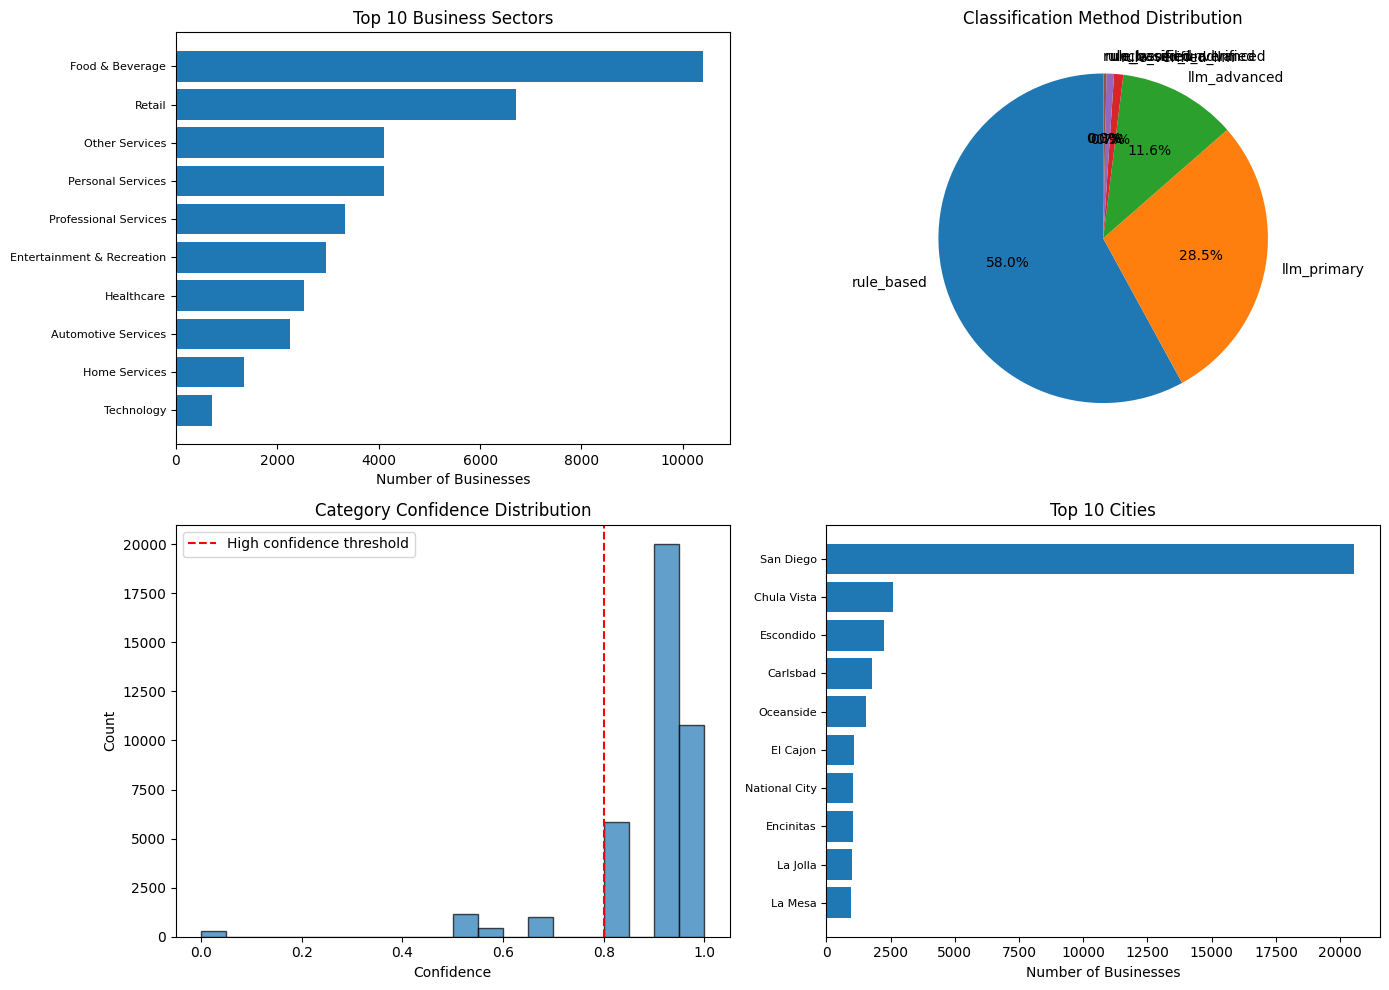

Visualizations complete.


In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Top sectors
top_sectors = df['category_sector'].value_counts().head(10)
axes[0, 0].barh(range(len(top_sectors)), top_sectors.values)
axes[0, 0].set_yticks(range(len(top_sectors)))
axes[0, 0].set_yticklabels(top_sectors.index, fontsize=8)
axes[0, 0].set_xlabel('Number of Businesses')
axes[0, 0].set_title('Top 10 Business Sectors')
axes[0, 0].invert_yaxis()

# 2. Classification method distribution
method_counts = df['category_method'].value_counts()
axes[0, 1].pie(method_counts.values, labels=method_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Classification Method Distribution')

# 3. Confidence distribution
axes[1, 0].hist(df['category_confidence'], bins=20, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0.8, color='red', linestyle='--', label='High confidence threshold')
axes[1, 0].set_xlabel('Confidence')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Category Confidence Distribution')
axes[1, 0].legend()

# 4. Top cities
top_cities = df['city'].value_counts().head(10)
axes[1, 1].barh(range(len(top_cities)), top_cities.values)
axes[1, 1].set_yticks(range(len(top_cities)))
axes[1, 1].set_yticklabels(top_cities.index, fontsize=8)
axes[1, 1].set_xlabel('Number of Businesses')
axes[1, 1].set_title('Top 10 Cities')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

print('Visualizations complete.')

## Miscellaneous Visualizations

Visual analysis of miscellaneous businesses - patterns, franchise breakdown, and geographic distribution.

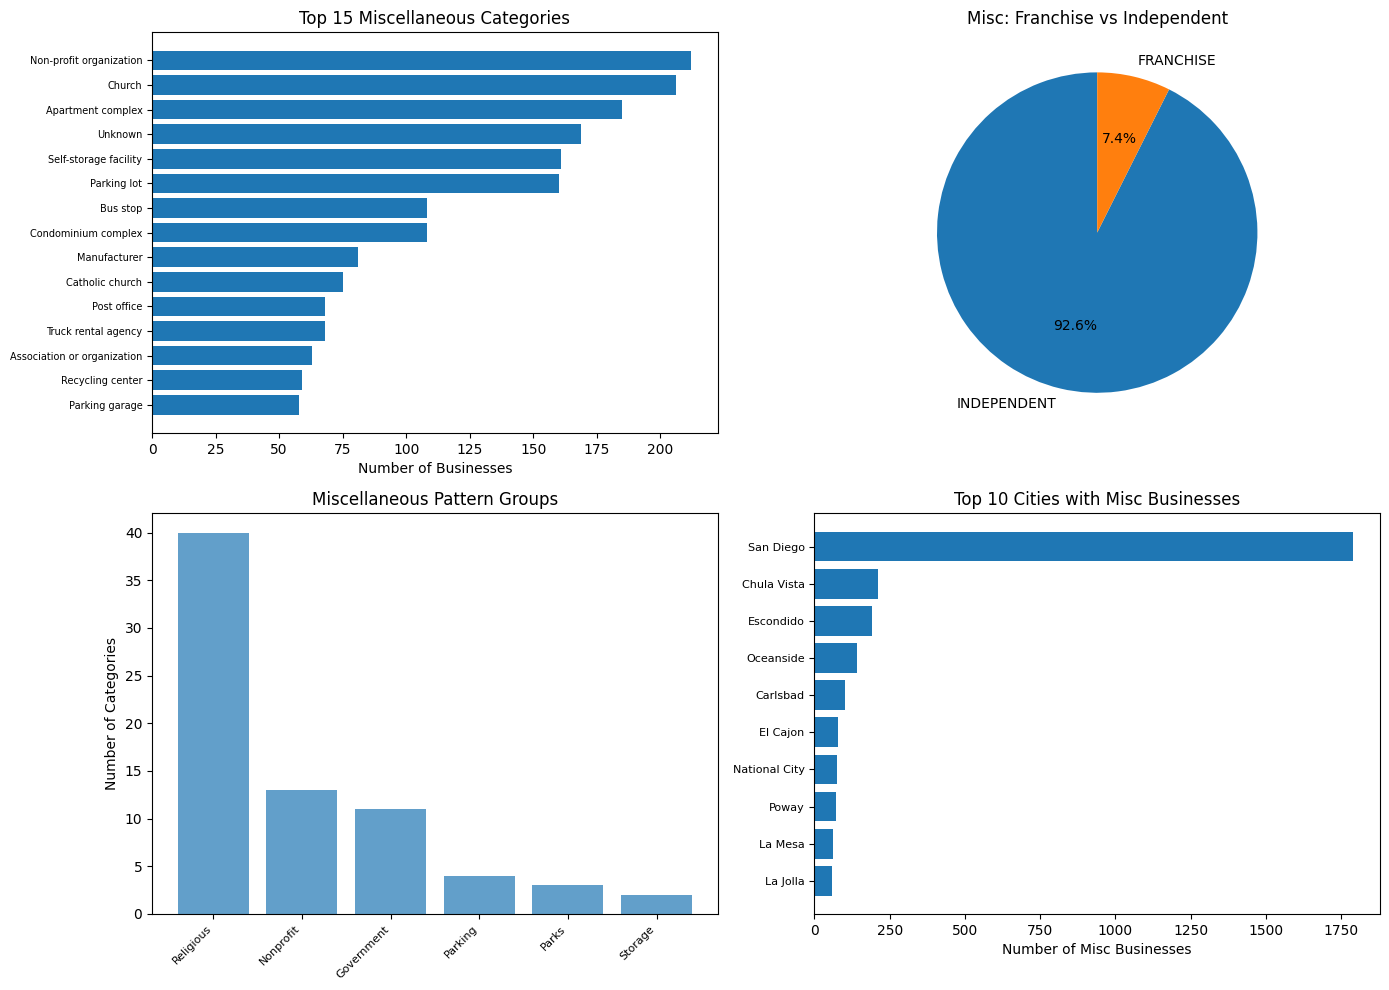

Miscellaneous visualizations complete.

Miscellaneous Analysis Summary:
  Total misc businesses: 3,268
  Percentage of total: 8.3%
  Unique categories: 202
  AI recommendation: Current taxonomy sufficient or recommendations unavailable


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Top miscellaneous categories
top_misc = df_misc['category_original'].value_counts().head(15)
axes[0, 0].barh(range(len(top_misc)), top_misc.values)
axes[0, 0].set_yticks(range(len(top_misc)))
axes[0, 0].set_yticklabels(top_misc.index, fontsize=7)
axes[0, 0].set_xlabel('Number of Businesses')
axes[0, 0].set_title('Top 15 Miscellaneous Categories')
axes[0, 0].invert_yaxis()

# 2. Franchise vs Independent in misc
if len(misc_franchise) > 0:
    franchise_counts = misc_franchise['franchise_type'].value_counts()
    axes[0, 1].pie(franchise_counts.values, labels=franchise_counts.index, autopct='%1.1f%%', startangle=90)
    axes[0, 1].set_title('Misc: Franchise vs Independent')
else:
    axes[0, 1].text(0.5, 0.5, 'No franchise data available', ha='center', va='center')
    axes[0, 1].set_title('Misc: Franchise vs Independent')

# 3. Pattern groups
if patterns:
    pattern_counts = {p: len(cats) for p, cats in patterns.items() if p != 'Other'}
    if pattern_counts:
        pattern_names = list(pattern_counts.keys())
        pattern_values = list(pattern_counts.values())
        axes[1, 0].bar(range(len(pattern_names)), pattern_values, alpha=0.7)
        axes[1, 0].set_xticks(range(len(pattern_names)))
        axes[1, 0].set_xticklabels(pattern_names, rotation=45, ha='right', fontsize=8)
        axes[1, 0].set_ylabel('Number of Categories')
        axes[1, 0].set_title('Miscellaneous Pattern Groups')
    else:
        axes[1, 0].text(0.5, 0.5, 'No patterns identified', ha='center', va='center')
        axes[1, 0].set_title('Miscellaneous Pattern Groups')
else:
    axes[1, 0].text(0.5, 0.5, 'No patterns identified', ha='center', va='center')
    axes[1, 0].set_title('Miscellaneous Pattern Groups')

# 4. Top cities with misc businesses
misc_cities = df_misc['city'].value_counts().head(10)
axes[1, 1].barh(range(len(misc_cities)), misc_cities.values)
axes[1, 1].set_yticks(range(len(misc_cities)))
axes[1, 1].set_yticklabels(misc_cities.index, fontsize=8)
axes[1, 1].set_xlabel('Number of Misc Businesses')
axes[1, 1].set_title('Top 10 Cities with Misc Businesses')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

print('Miscellaneous visualizations complete.')
print(f'\nMiscellaneous Analysis Summary:')
print(f'  Total misc businesses: {len(df_misc):,}')
print(f'  Percentage of total: {len(df_misc)/len(df)*100:.1f}%')
print(f'  Unique categories: {df_misc["category_original"].nunique()}')
if taxonomy_recommendations and taxonomy_recommendations.get('should_expand'):
    print(f'  AI recommendation: Expand taxonomy')
    print(f'  Suggested additions: {len(taxonomy_recommendations.get("recommended_additions", []))} new subsectors')
else:
    print(f'  AI recommendation: Current taxonomy sufficient or recommendations unavailable')

## Formatted Taxonomy Additions

Ready-to-use Python code for recommended taxonomy additions. Copy and paste into the CANONICAL_TAXONOMY dictionary.

In [24]:
if taxonomy_recommendations and taxonomy_recommendations.get('recommended_additions'):
    print("="*70)
    print("FORMATTED TAXONOMY ADDITIONS")
    print("="*70)
    print("\nCopy the following code into your CANONICAL_TAXONOMY dictionary:\n")
    print("```python")
    print("CANONICAL_TAXONOMY = {")
    
    # Group recommendations by sector
    by_sector = defaultdict(list)
    for rec in taxonomy_recommendations['recommended_additions']:
        by_sector[rec.get('sector', 'Other Services')].append(rec)
    
    for sector, recs in by_sector.items():
        print(f'    "{sector}": {{')
        for rec in recs:
            subsector = rec.get('subsector', 'Unknown')
            keywords = rec.get('keywords', [])
            print(f'        "{subsector}": {json.dumps(keywords)},')
        print('    },')
    
    print("    # ... rest of taxonomy ...")
    print("}")
    print("```")
    
    # Also save to file if in full mode
    if OUTPUT_MODE.lower() == 'full':
        additions_file = os.path.join(OUTPUT_DIR, 'taxonomy_recommendations.json')
        with open(additions_file, 'w', encoding='utf-8') as f:
            json.dump(taxonomy_recommendations, f, indent=2, ensure_ascii=False)
        print(f"\nFull recommendations saved to: {additions_file}")
    
    # Show impact estimate
    print("\n" + "="*70)
    print("ESTIMATED IMPACT")
    print("="*70)
    total_addressable = sum(rec.get('business_count', 0) for rec in taxonomy_recommendations['recommended_additions'])
    print(f"\nEstimated businesses that would be reclassified: ~{total_addressable}")
    print(f"Current miscellaneous: {len(df_misc)}")
    print(f"Potential reduction: {total_addressable/len(df_misc)*100:.1f}%")
    
else:
    print("No taxonomy additions recommended or recommendations not available")

No taxonomy additions recommended or recommendations not available


## AI Taxonomy Recommendations

Use AI to analyze miscellaneous patterns and recommend taxonomy improvements. The LLM receives:
- Current taxonomy structure
- Statistics on miscellaneous categories
- Franchise vs independent breakdown
- Common patterns and keywords

The AI provides:
- Assessment of taxonomy coverage
- Recommendations for new categories
- Formatted taxonomy additions ready to implement

In [25]:
async def get_taxonomy_recommendations():
    """Get AI recommendations for taxonomy improvements based on misc patterns."""
    if not client:
        print("OpenAI client not available - skipping taxonomy recommendations")
        return None
    
    # Prepare statistics for LLM
    stats = {
        "total_businesses": len(df),
        "misc_businesses": len(df_misc),
        "misc_percentage": f"{len(df_misc)/len(df)*100:.1f}%",
        "unique_misc_categories": df_misc['category_original'].nunique(),
        "top_misc_categories": [
            {"category": cat, "count": int(count)} 
            for cat, count in df_misc['category_original'].value_counts().head(20).items()
        ],
        "pattern_groups": {
            pattern: {
                "unique_categories": len(cats),
                "business_count": df_misc[df_misc['category_original'].isin(cats)].shape[0]
            }
            for pattern, cats in patterns.items() if pattern != 'Other'
        },
        "franchise_breakdown": {
            "franchises": int((misc_franchise['franchise_type'] == 'FRANCHISE').sum()) if len(misc_franchise) > 0 else 0,
            "independent": int((misc_franchise['franchise_type'] == 'INDEPENDENT').sum()) if len(misc_franchise) > 0 else 0
        }
    }
    
    # Build current taxonomy summary
    taxonomy_summary = {}
    for sector, subsectors in CANONICAL_TAXONOMY.items():
        taxonomy_summary[sector] = list(subsectors.keys())
    
    # Create prompt for LLM
    system_msg = """You are a business taxonomy expert. Analyze the provided statistics about businesses currently classified as "Miscellaneous" and assess whether the current taxonomy should be expanded.

Provide your response in this exact JSON format:
{
  "assessment": {
    "taxonomy_coverage": "brief assessment of current coverage",
    "should_expand": true/false,
    "reasoning": "explanation of recommendation"
  },
  "recommended_additions": [
    {
      "sector": "sector name (existing or NEW)",
      "subsector": "new subsector name",
      "keywords": ["keyword1", "keyword2", ...],
      "justification": "why this addition is recommended",
      "business_count": estimated_number,
      "confidence": "high/medium/low"
    }
  ]
}

Only recommend additions if there are clear, substantial patterns with 20+ businesses. Focus on business-relevant categories, avoid overly specific or rare types."""
    
    user_msg = f"""Current Taxonomy:
{json.dumps(taxonomy_summary, indent=2)}

Miscellaneous Business Statistics:
{json.dumps(stats, indent=2)}

Based on these statistics, should we expand the taxonomy? What new sectors or subsectors would you recommend?"""
    
    try:
        print("Analyzing miscellaneous patterns with AI...")
        async with semaphore:
            response = await client.chat.completions.create(
                model=ADVANCED_MODEL,
                messages=[
                    {"role": "system", "content": system_msg},
                    {"role": "user", "content": user_msg},
                ],
                temperature=0.3
            )
        
        result_text = response.choices[0].message.content.strip()
        
        # Extract JSON from response
        try:
            result = json.loads(result_text)
        except json.JSONDecodeError:
            json_match = re.search(r'\{.*\}', result_text, re.DOTALL)
            if json_match:
                result = json.loads(json_match.group())
            else:
                print("Failed to parse LLM response")
                return None
        
        return result
    
    except Exception as e:
        print(f"Error getting taxonomy recommendations: {e}")
        return None

# Get recommendations
taxonomy_recommendations = await get_taxonomy_recommendations()

if taxonomy_recommendations:
    assessment = taxonomy_recommendations.get('assessment', {})
    print("\n" + "="*70)
    print("TAXONOMY ASSESSMENT")
    print("="*70)
    print(f"\nCurrent Coverage: {assessment.get('taxonomy_coverage', 'N/A')}")
    print(f"\nShould Expand: {'YES' if assessment.get('should_expand') else 'NO'}")
    print(f"\nReasoning:")
    print(f"  {assessment.get('reasoning', 'N/A')}")
    
    recommendations = taxonomy_recommendations.get('recommended_additions', [])
    if recommendations:
        print("\n" + "="*70)
        print(f"RECOMMENDED ADDITIONS ({len(recommendations)} recommendations)")
        print("="*70)
        for i, rec in enumerate(recommendations, 1):
            print(f"\n{i}. {rec.get('sector')} -> {rec.get('subsector')}")
            print(f"   Confidence: {rec.get('confidence', 'N/A').upper()}")
            print(f"   Est. Businesses: ~{rec.get('business_count', 'N/A')}")
            print(f"   Keywords: {', '.join(rec.get('keywords', []))}")
            print(f"   Justification: {rec.get('justification', 'N/A')}")
    else:
        print("\nNo additions recommended - current taxonomy appears sufficient")
else:
    print("\nTaxonomy recommendations not available (requires OpenAI API)")

Analyzing miscellaneous patterns with AI...

TAXONOMY ASSESSMENT

Current Coverage: The current taxonomy covers a wide range of business sectors, but the 'Miscellaneous' category contains a significant number of businesses, indicating potential gaps.

Should Expand: YES

Reasoning:
  The 'Miscellaneous' category contains over 8% of businesses, with several distinct patterns emerging, such as religious organizations, nonprofits, and parking facilities. These patterns suggest the need for more specific classifications to improve business categorization and data utility.

RECOMMENDED ADDITIONS (5 recommendations)

1. Community & Religious Organizations -> Religious Organizations
   Confidence: HIGH
   Est. Businesses: ~627
   Keywords: church, religious organization, catholic church
   Justification: Religious organizations account for a significant portion of the 'Miscellaneous' category, with 627 businesses identified. Creating a dedicated subsector will improve classification accuracy.

## Pattern Analysis

Group miscellaneous categories by common patterns and keywords to identify potential new taxonomy categories.

In [26]:
# Analyze patterns in miscellaneous categories
import re

# Extract common keywords from misc categories
keywords = defaultdict(list)
for cat in df_misc['category_original'].unique():
    cat_lower = cat.lower()
    # Extract meaningful words (3+ chars, not common suffixes)
    words = re.findall(r'\b[a-z]{3,}\b', cat_lower)
    words = [w for w in words if w not in ['store', 'shop', 'service', 'services', 'center', 'company']]
    for word in words:
        keywords[word].append(cat)

# Find keywords that appear frequently
keyword_counts = {k: len(v) for k, v in keywords.items()}
common_keywords = sorted(keyword_counts.items(), key=lambda x: x[1], reverse=True)[:30]

print("Top 30 Keywords in Miscellaneous Categories:")
print("="*70)
for i, (keyword, count) in enumerate(common_keywords, 1):
    # Get sample categories
    sample_cats = keywords[keyword][:3]
    print(f"{i:2}. {keyword:20} ({count:3} categories)")
    for cat in sample_cats:
        print(f"    - {cat}")
    print()

# Group by major category patterns
patterns = defaultdict(list)
for cat in df_misc['category_original'].unique():
    cat_lower = cat.lower()
    # Detect patterns
    if any(w in cat_lower for w in ['parking', 'lot', 'garage']):
        patterns['Parking'].append(cat)
    elif any(w in cat_lower for w in ['storage', 'warehouse', 'facility']):
        patterns['Storage'].append(cat)
    elif any(w in cat_lower for w in ['church', 'religious', 'worship', 'temple', 'mosque', 'synagogue']):
        patterns['Religious'].append(cat)
    elif any(w in cat_lower for w in ['nonprofit', 'charity', 'foundation', 'organization']):
        patterns['Nonprofit'].append(cat)
    elif any(w in cat_lower for w in ['government', 'municipal', 'public', 'city', 'county']):
        patterns['Government'].append(cat)
    elif any(w in cat_lower for w in ['park', 'playground', 'trail']):
        patterns['Parks'].append(cat)
    else:
        patterns['Other'].append(cat)

print("\n" + "="*70)
print("Major Category Groups in Miscellaneous:")
print("="*70)
for pattern, cats in sorted(patterns.items(), key=lambda x: len(x[1]), reverse=True):
    if pattern != 'Other':
        count = df_misc[df_misc['category_original'].isin(cats)].shape[0]
        print(f"\n{pattern}: {len(cats)} unique categories, {count} businesses")
        # Show top 5 categories in this group
        top_in_group = df_misc[df_misc['category_original'].isin(cats)]['category_original'].value_counts().head(5)
        for cat, cnt in top_in_group.items():
            print(f"  - {cat}: {cnt} businesses")

Top 30 Keywords in Miscellaneous Categories:
 1. church               ( 32 categories)
    - Christian church
    - Church of the Nazarene
    - Church

 2. repair               ( 14 categories)
    - Appliance repair service
    - Shoe repair shop
    - Clock repair service

 3. office               ( 13 categories)
    - County government office
    - Post office
    - Government office

 4. organization         ( 11 categories)
    - Non-profit organization
    - Veterans organization
    - Social services organization

 5. department           (  9 categories)
    - Sheriff's department
    - Department of motor vehicles
    - Police department

 6. government           (  8 categories)
    - County government office
    - Government office
    - State government office

 7. orthodox             (  5 categories)
    - Orthodox church
    - Russian Orthodox church
    - Eastern Orthodox Church

 8. complex              (  4 categories)
    - Condominium complex
    - Apartment compl

In [27]:
# Remove temporary analysis columns
print("\nPreparing final output...")
print(f"  Removing analysis columns: category_method, category_confidence")

final_businesses = []
for business in standardized_businesses:
    clean_business = {
        "id": business["id"],
        "business_name": business["business_name"],
        "url": business["url"],
        "address": business["address"],
        "city": business["city"],
        "zip_code": business["zip_code"],
        "latitude": business["latitude"],
        "longitude": business["longitude"],
        "blockgroup": business["blockgroup"],
        "avg_rating": business["avg_rating"],
        "geom": business["geom"],
        "franchise_type": business["franchise_type"],
        "is_franchise": business["is_franchise"],
        "has_valid_coordinates": business["has_valid_coordinates"],
        "category_original": business["category_original"],
        "category_sector": business["category_sector"],
        "category_subsector": business["category_subsector"]
    }
    final_businesses.append(clean_business)

# Save final clean output
final_output_file = os.path.join(OUTPUT_DIR, OUTPUT_FILENAME)
print(f"\nSaving final output to {final_output_file}")

with open(final_output_file, 'w', encoding='utf-8') as f:
    json.dump(final_businesses, f, indent=2, ensure_ascii=False)

print(f"Saved {len(final_businesses):,} businesses")
print(f"\nFinal output complete - analysis columns removed")


Preparing final output...
  Removing analysis columns: category_method, category_confidence

Saving final output to ../data/llm\sd_businesses.json
Saved 39,593 businesses

Final output complete - analysis columns removed
